<a href="https://colab.research.google.com/github/Adithyanbiju10/AI_ML_Internship/blob/main/titanic_day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
df=pd.read_csv("/content/titanic uncleaned.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df['Age_mean_imputed']=df['Age'].fillna(df['Age'].mean())
df['Age_median_imputed']=df['Age'].fillna(df['Age'].median())

In [ ]:
df['Cabin_mode_imputed']=df['Cabin'].fillna(df['Cabin'].mode()[0])

In [ ]:
df[['Age','Age_mean_imputed','Age_median_imputed']]

,Age,Age_mean_imputed,Age_median_imputed
0,34.5,34.50000,34.5
1,47.0,47.00000,47.0
2,62.0,62.00000,62.0
3,27.0,27.00000,27.0
4,22.0,22.00000,22.0
...,...,...,...
413,NaN,30.27259,27.0
414,39.0,39.00000,39.0
415,38.5,38.50000,38.5
416,NaN,30.27259,27.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="whitegrid")


/tmp/ipykernel_6170/1514122504.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Pclass',y='Survived',palette='pastel')


Text(0, 0.5, 'Surviver')

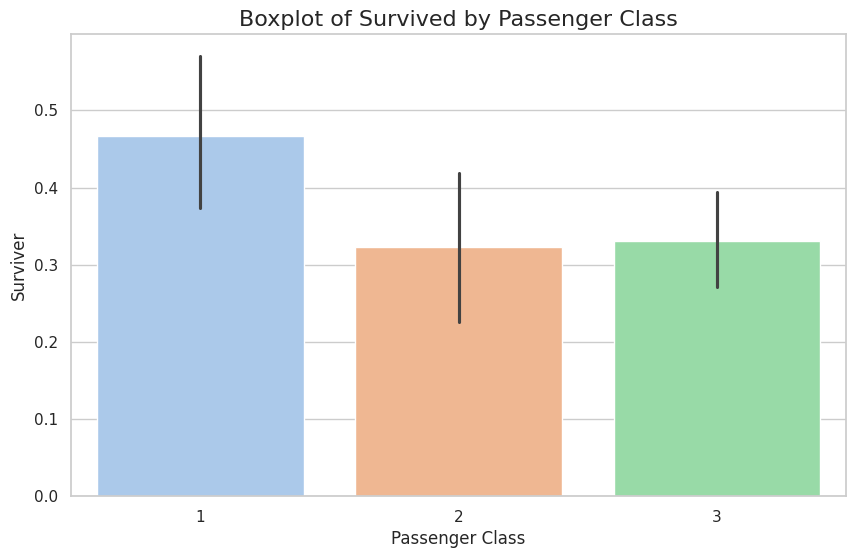

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Pclass',y='Survived',palette='pastel')

plt.title('Boxplot of Survived by Passenger Class',fontsize=16)
plt.xlabel('Passenger Class',fontsize=12)
plt.ylabel('Surviver',fontsize=12)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encode_data=df.copy()

In [ ]:
label_encoder=LabelEncoder()
encode_data['Sex_Label']=label_encoder.fit_transform(encode_data['Sex'])

one_hot_encoded=pd.get_dummies(encode_data['Embarked'],prefix='Embarked')
encode_data=pd.concat([encode_data,one_hot_encoded],axis=1)

pclass_mapping={1:'First',2:'Second',3:'Third'}
encode_data['Pclass_Category']=encode_data['Pclass'].map(pclass_mapping)

In [ ]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [ ]:
file_path="/content/titanic uncleaned.csv"

In [ ]:
titanic_data=pd.read_csv(file_path)


In [ ]:
numerical_columns=['Age','Fare','Pclass']

In [ ]:
titanic_data.dropna(subset=numerical_columns,inplace=True)

In [ ]:
minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()



In [ ]:
titanic_data['Age_MinMax']=minmax_scaler.fit_transform(titanic_data[['Age']])
titanic_data['Fare_MinMax']=minmax_scaler.fit_transform(titanic_data[['Fare']])
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_MinMax,Fare_MinMax
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0.452723,0.015282
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0.617566,0.013663
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0.815377,0.018909
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0.353818,0.016908
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0.287881,0.023984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S,0.037320,0.026887
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q,0.485692,0.175668
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,0.367005,0.015176
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0.512066,0.212559


In [ ]:
titanic_data['Age_Standard']=standard_scaler.fit_transform(titanic_data[['Age']])
titanic_data['Fare_Standard']=standard_scaler.fit_transform(titanic_data[['Fare']])
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_MinMax,Fare_MinMax,Age_Standard,Fare_Standard
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0.452723,0.015282,0.306657,-0.542281
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0.617566,0.013663,1.194236,-0.555844
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0.815377,0.018909,2.259331,-0.511885
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0.353818,0.016908,-0.225890,-0.528651
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0.287881,0.023984,-0.580922,-0.469357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S,0.037320,0.026887,-1.930042,-0.445026
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q,0.485692,0.175668,0.484173,0.801785
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,0.367005,0.015176,-0.154884,-0.543168
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0.512066,0.212559,0.626186,1.110932


In [ ]:
titanic_data[['Age','Age_MinMax','Age_Standard']]

,Age,Age_MinMax,Age_Standard
0,34.5,0.452723,0.306657
1,47.0,0.617566,1.194236
2,62.0,0.815377,2.259331
3,27.0,0.353818,-0.225890
4,22.0,0.287881,-0.580922
...,...,...,...
409,3.0,0.037320,-1.930042
411,37.0,0.485692,0.484173
412,28.0,0.367005,-0.154884
414,39.0,0.512066,0.626186
